In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [2]:
df=pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.isnull().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
# 4. Handle invalid zero values
# In diabetes data, some medical columns may contain 0 as missing
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in zero_columns:
    df[col] = df[col].replace(0, np.nan)

# 5. Fill missing values using median
for col in zero_columns:
    df[col] = df[col].fillna(df[col].median())

# 6. Split features and target
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

In [28]:
models = {}

for test_size in [0.2, 0.25, 0.3]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    classifier_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
    classifier_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)

    classifier_gini.fit(X_train, y_train)
    classifier_entropy.fit(X_train, y_train)

    models[test_size] = {
        "gini": classifier_gini,
        "entropy": classifier_entropy
    }

    y_pred_gini = classifier_gini.predict(X_test)
    y_pred_entropy = classifier_entropy.predict(X_test)

    print(f"\nTest size = {test_size}")
    print("Gini Accuracy:", accuracy_score(y_test, y_pred_gini))
    print("Entropy Accuracy:", accuracy_score(y_test, y_pred_entropy))
    print("\nGini Classification Report:\n", classification_report(y_test, y_pred_gini))
    print("\nEntropy Classification Report:\n", classification_report(y_test, y_pred_entropy))


Test size = 0.2
Gini Accuracy: 0.6818181818181818
Entropy Accuracy: 0.6753246753246753

Gini Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.79      0.76       100
           1       0.55      0.48      0.51        54

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154


Entropy Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.76      0.75       100
           1       0.54      0.52      0.53        54

    accuracy                           0.68       154
   macro avg       0.64      0.64      0.64       154
weighted avg       0.67      0.68      0.67       154


Test size = 0.25
Gini Accuracy: 0.6875
Entropy Accuracy: 0.6979166666666666

Gini Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.82

In [29]:
new_sample = np.array([[6, 148, 72, 35, 0, 33.6, 0.627, 50]])

for test_size, model_dict in models.items():
    prediction = model_dict["gini"].predict(new_sample)
    prediction_entropy = model_dict["entropy"].predict(new_sample)

    print(f"\nFor test size = {test_size}")
    print("Gini prediction:", prediction)
    print("Entropy prediction:", prediction_entropy)

    if prediction[0] == 1:
        print("The patient is predicted to have diabetes (Gini).")
    else:
        print("The patient is predicted to not have diabetes (Gini).")

    if prediction_entropy[0] == 1:
        print("The patient is predicted to have diabetes (Entropy).")
    else:
        print("The patient is predicted to not have diabetes (Entropy).")


For test size = 0.2
Gini prediction: [1]
Entropy prediction: [1]
The patient is predicted to have diabetes (Gini).
The patient is predicted to have diabetes (Entropy).

For test size = 0.25
Gini prediction: [1]
Entropy prediction: [0]
The patient is predicted to have diabetes (Gini).
The patient is predicted to not have diabetes (Entropy).

For test size = 0.3
Gini prediction: [0]
Entropy prediction: [1]
The patient is predicted to not have diabetes (Gini).
The patient is predicted to have diabetes (Entropy).


d:\AML-Lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\AML-Lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\AML-Lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\AML-Lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\AML-Lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\AML-Lab\.venv\Lib\site-packages\


Tree for test_size = 0.2


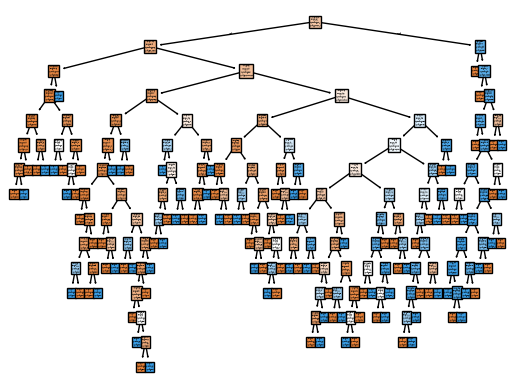

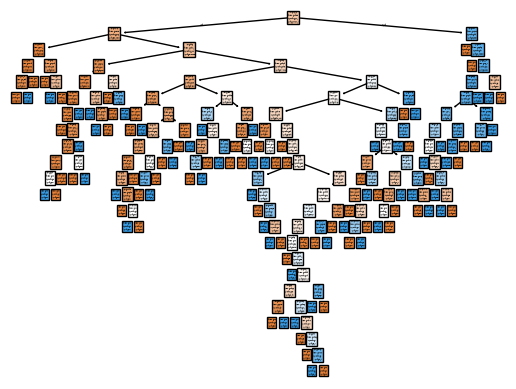


Tree for test_size = 0.25


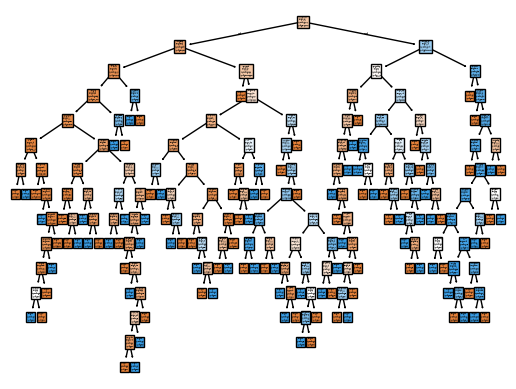

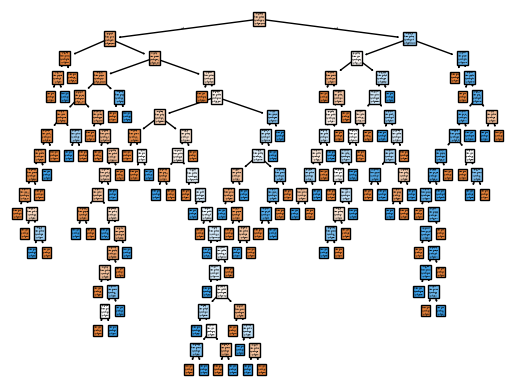


Tree for test_size = 0.3


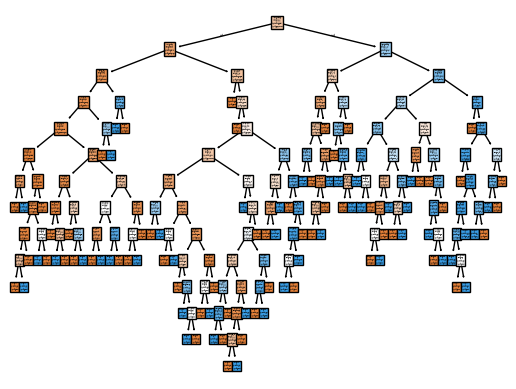

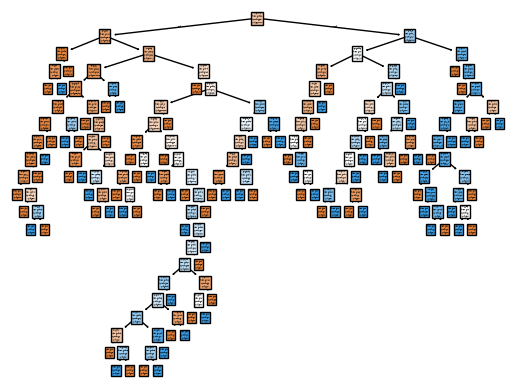

In [30]:
for test_size, model_dict in models.items():
    print(f"\nTree for test_size = {test_size}")
    tree.plot_tree(model_dict["gini"], filled=True)
    plt.show()

    tree.plot_tree(model_dict["entropy"], filled=True)
    plt.show()
